<a href="https://colab.research.google.com/github/emersonnjsantos/visao-computacional-tic43/blob/main/notebooks/relatorio_atividade_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# 1. Clonar o repositório com o dataset
!git clone https://github.com/emersonnjsantos/visao-computacional-tic43.git
%cd visao-computacional-tic43

# 2. Importar bibliotecas necessárias
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Configuração de exibição dos gráficos
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['image.cmap'] = 'gray'

print("Repositório clonado e bibliotecas importadas com sucesso!")

Cloning into 'visao-computacional-tic43'...
remote: Enumerating objects: 21, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 21 (delta 3), reused 21 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (21/21), 1.42 MiB | 23.46 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/visao-computacional-tic43/visao-computacional-tic43
Repositório clonado e bibliotecas importadas com sucesso!


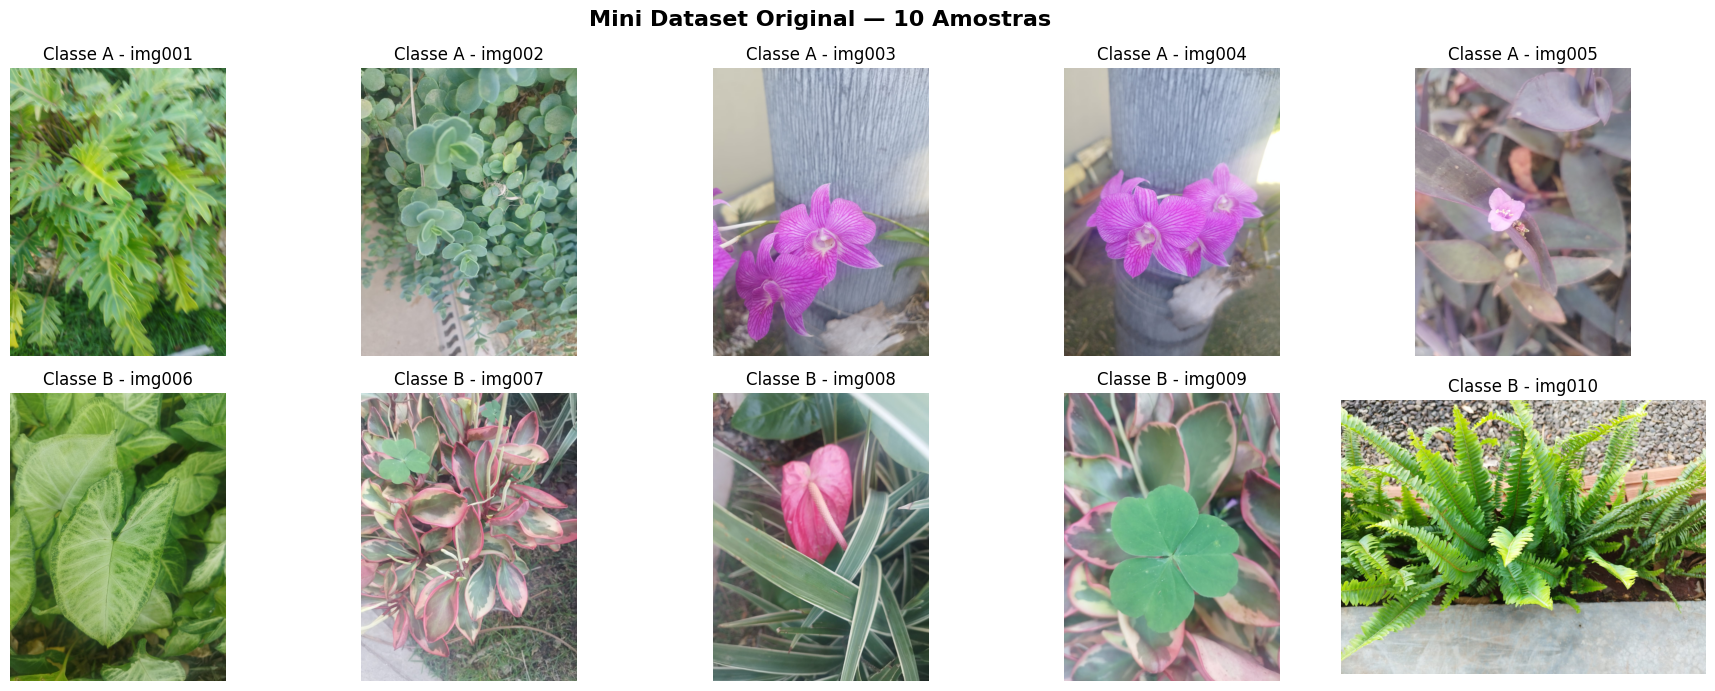

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

# Exibir Classe A (img001 a img005)
for i in range(1, 6):
    caminho = f"dataset/classe_A/img{i:03d}_original.jpg"
    img = cv2.imread(caminho)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[0, i-1].imshow(img_rgb)
        axes[0, i-1].set_title(f"Classe A - img{i:03d}")
    axes[0, i-1].axis('off')

# Exibir Classe B (img006 a img010)
for i in range(6, 11):
    caminho = f"dataset/classe_B/img{i:03d}_original.jpg"
    img = cv2.imread(caminho)
    if img is not None:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[1, i-6].imshow(img_rgb)
        axes[1, i-6].set_title(f"Classe B - img{i:03d}")
    axes[1, i-6].axis('off')

plt.suptitle("Mini Dataset Original — 10 Amostras", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
import os
from IPython.display import Markdown

img_a = cv2.imread("dataset/classe_A/img001_original.jpg")
img_b = cv2.imread("dataset/classe_B/img006_original.jpg")

os.makedirs("outputs/formatos", exist_ok=True)

def processar_formatos(img, nome_classe):
    caminho_jpg = f"outputs/formatos/{nome_classe}_comprimido.jpg"
    caminho_png = f"outputs/formatos/{nome_classe}_sem_perdas.png"

    # Salvar em JPEG com compressão (qualidade 50) e PNG sem perdas
    cv2.imwrite(caminho_jpg, img, [cv2.IMWRITE_JPEG_QUALITY, 50])
    cv2.imwrite(caminho_png, img, [cv2.IMWRITE_PNG_COMPRESSION, 3])

    tam_jpg = os.path.getsize(caminho_jpg) / 1024
    tam_png = os.path.getsize(caminho_png) / 1024

    print(f"[{nome_classe.upper()}]")
    print(f" - Tamanho JPEG comprimido: {tam_jpg:.2f} KB")
    print(f" - Tamanho PNG sem perdas:   {tam_png:.2f} KB")
    print(f" - Razão PNG/JPEG:          {tam_png / tam_jpg:.2f}x\n")

processar_formatos(img_a, "classe_A")
processar_formatos(img_b, "classe_B")

display(Markdown("""
### Análise Técnica: Formatos de Arquivo
* **Tamanho do Arquivo:** O PNG é consideravelmente maior que o JPEG devido à compressão sem perdas (lossless).
* **Diferença Visual:** O JPEG introduz artefatos de bloco (8x8) e ruído de alta frequência ao redor de bordas. O PNG preserva 100% dos valores numéricos originais de cada pixel.
* **Impacto em PDI:** JPEG é adequado para datasets massivos de classificação. PNG é mandatório em aplicações médicas, metrologia e visão industrial de precisão.
"""))

[CLASSE_A]
 - Tamanho JPEG comprimido: 117.01 KB
 - Tamanho PNG sem perdas:   2158.86 KB
 - Razão PNG/JPEG:          18.45x

[CLASSE_B]
 - Tamanho JPEG comprimido: 131.83 KB
 - Tamanho PNG sem perdas:   1999.73 KB
 - Razão PNG/JPEG:          15.17x




### Análise Técnica: Formatos de Arquivo
* **Tamanho do Arquivo:** O PNG é consideravelmente maior que o JPEG devido à compressão sem perdas (lossless).
* **Diferença Visual:** O JPEG introduz artefatos de bloco (8x8) e ruído de alta frequência ao redor de bordas. O PNG preserva 100% dos valores numéricos originais de cada pixel.
* **Impacto em PDI:** JPEG é adequado para datasets massivos de classificação. PNG é mandatório em aplicações médicas, metrologia e visão industrial de precisão.


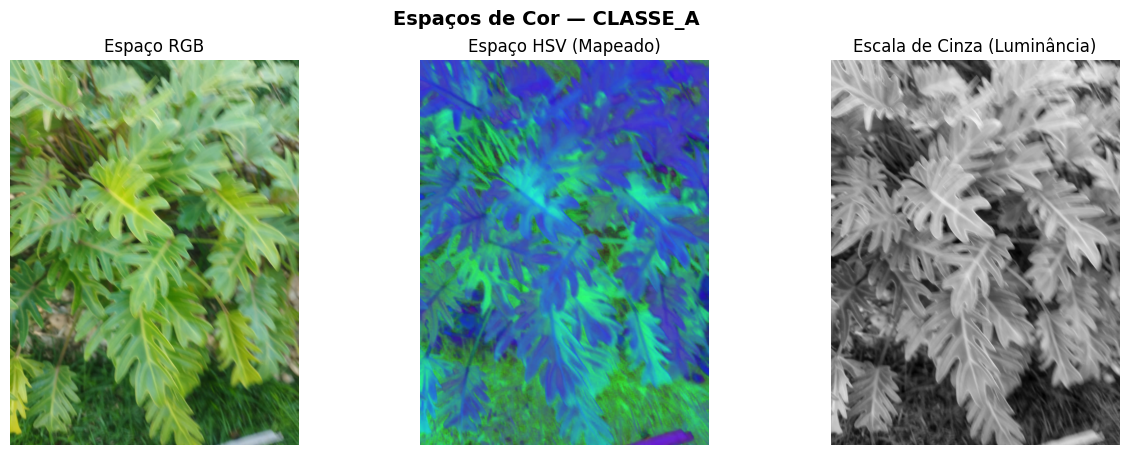

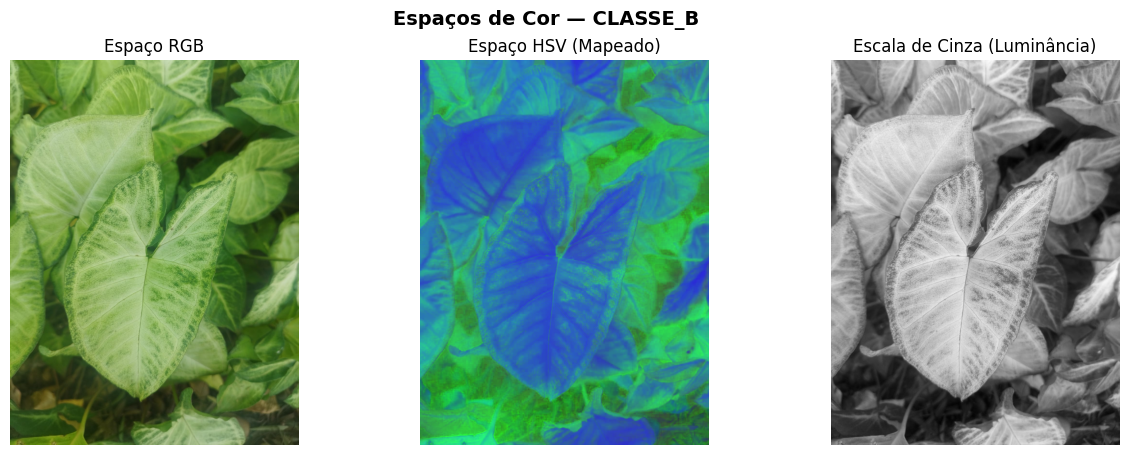


### Análise Técnica: Espaços de Cor
* **Diferenças visuais:** RGB mistura cor e intensidade em 3 canais. HSV separa a cor pura (Hue/Matiz) e pureza (Saturation) da luminosidade (Value). A escala de cinza condensa tudo em uma matriz 2D de brilho.
* **Aplicações:** 
  * **HSV:** Segmentação e rastreamento por cor resistente a variações de sombra.
  * **Escala de Cinza:** Filtros de borda (Sobel, Canny), extração de cantos e redução do custo computacional de 3 canais para 1.
  * **RGB:** Modelos pré-treinados de Deep Learning (ResNet, YOLO).


In [18]:
import os
from IPython.display import Markdown

def processar_espaco_cor(img, nome_classe):
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    os.makedirs("outputs/espaco_cor", exist_ok=True)

    cv2.imwrite(f"outputs/espaco_cor/{nome_classe}_rgb.jpg", cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))
    cv2.imwrite(f"outputs/espaco_cor/{nome_classe}_hsv.jpg", cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR))
    cv2.imwrite(f"outputs/espaco_cor/{nome_classe}_gray.jpg", gray)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(rgb)
    axes[0].set_title("Espaço RGB")
    axes[0].axis('off')

    axes[1].imshow(hsv)
    axes[1].set_title("Espaço HSV (Mapeado)")
    axes[1].axis('off')

    axes[2].imshow(gray, cmap='gray')
    axes[2].set_title("Escala de Cinza (Luminância)")
    axes[2].axis('off')

    plt.suptitle(f"Espaços de Cor — {nome_classe.upper()}", fontsize=14, fontweight='bold')
    plt.show()

processar_espaco_cor(img_a, "classe_A")
processar_espaco_cor(img_b, "classe_B")

display(Markdown("""
### Análise Técnica: Espaços de Cor
* **Diferenças visuais:** RGB mistura cor e intensidade em 3 canais. HSV separa a cor pura (Hue/Matiz) e pureza (Saturation) da luminosidade (Value). A escala de cinza condensa tudo em uma matriz 2D de brilho.
* **Aplicações:**
  * **HSV:** Segmentação e rastreamento por cor resistente a variações de sombra.
  * **Escala de Cinza:** Filtros de borda (Sobel, Canny), extração de cantos e redução do custo computacional de 3 canais para 1.
  * **RGB:** Modelos pré-treinados de Deep Learning (ResNet, YOLO).
"""))

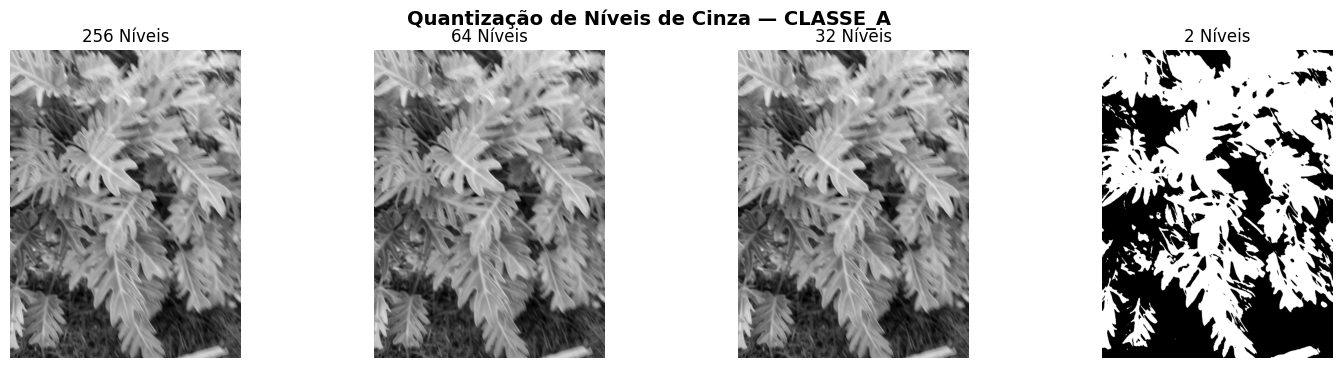

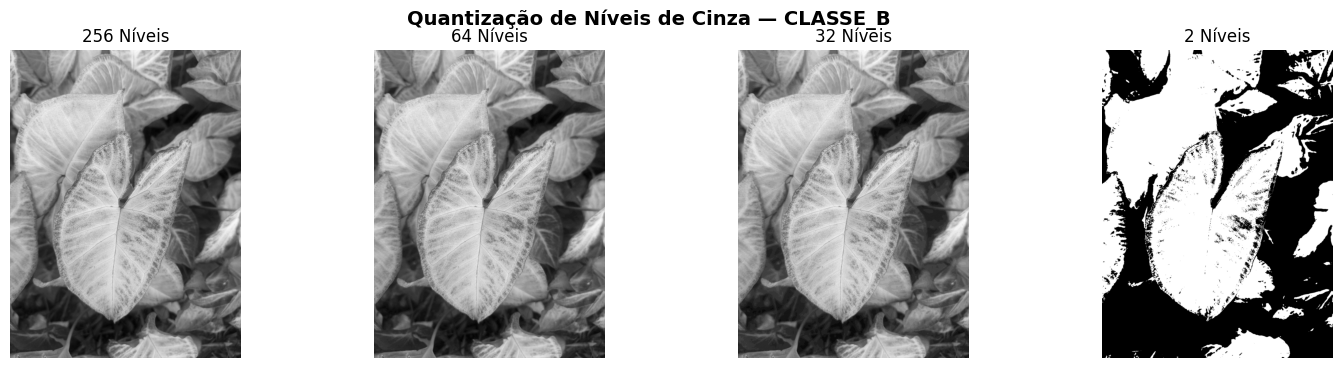


### Análise Técnica: Quantização
* **Efeitos visuais:** Em 64 e 32 níveis surge o efeito de falso contorno (*contouring/banding*). Em 2 níveis, a imagem é binarizada (preto/branco puro).
* **Versão mais útil:** 
  * **256 níveis:** Preserva gradientes essenciais para extrair texturas e classificar imagens.
  * **2 níveis:** Muito útil para binarização, cálculo de área e máscaras de segmentação direta.


In [19]:
def quantizar(img_gray, niveis):
    if niveis == 2:
        _, res = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)
        return res
    fator = 256 // niveis
    return (img_gray // fator) * fator

def processar_quantizacao(img, nome_classe):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    niveis = [256, 64, 32, 2]

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for idx, n in enumerate(niveis):
        quant = gray if n == 256 else quantizar(gray, n)
        cv2.imwrite(f"outputs/quantizacao/{nome_classe}_{n}niveis.png", quant)
        axes[idx].imshow(quant, cmap='gray')
        axes[idx].set_title(f"{n} Níveis")
        axes[idx].axis('off')

    plt.suptitle(f"Quantização de Níveis de Cinza — {nome_classe.upper()}", fontsize=14, fontweight='bold')
    plt.show()

processar_quantizacao(img_a, "classe_A")
processar_quantizacao(img_b, "classe_B")

display(Markdown("""
### Análise Técnica: Quantização
* **Efeitos visuais:** Em 64 e 32 níveis surge o efeito de falso contorno (*contouring/banding*). Em 2 níveis, a imagem é binarizada (preto/branco puro).
* **Versão mais útil:**
  * **256 níveis:** Preserva gradientes essenciais para extrair texturas e classificar imagens.
  * **2 níveis:** Muito útil para binarização, cálculo de área e máscaras de segmentação direta.
"""))

In [20]:
def processar_formatos(img, nome_classe):
    caminho_jpg = f"outputs/formatos/{nome_classe}_comprimido.jpg"
    caminho_png = f"outputs/formatos/{nome_classe}_sem_perdas.png"

    # Salvar em JPEG com compressão (qualidade 50) e PNG sem perdas
    cv2.imwrite(caminho_jpg, img, [cv2.IMWRITE_JPEG_QUALITY, 50])
    cv2.imwrite(caminho_png, img, [cv2.IMWRITE_PNG_COMPRESSION, 3])

    tam_jpg = os.path.getsize(caminho_jpg) / 1024
    tam_png = os.path.getsize(caminho_png) / 1024

    print(f"[{nome_classe.upper()}]")
    print(f" - Tamanho JPEG comprimido: {tam_jpg:.2f} KB")
    print(f" - Tamanho PNG sem perdas:   {tam_png:.2f} KB")
    print(f" - Razão PNG/JPEG:          {tam_png / tam_jpg:.2f}x\n")

processar_formatos(img_a, "classe_A")
processar_formatos(img_b, "classe_B")

display(Markdown("""
### Análise Técnica: Formatos de Arquivo
* **Tamanho do Arquivo:** O PNG é consideravelmente maior que o JPEG devido à compressão sem perdas (lossless).
* **Diferença Visual:** O JPEG introduz artefatos de bloco (8x8) e ruído de alta frequência ao redor de bordas. O PNG preserva 100% dos valores numéricos originais de cada pixel.
* **Impacto em PDI:** JPEG é adequado para datasets massivos de classificação. PNG é mandatório em aplicações médicas, metrologia e visão industrial de precisão.
"""))

[CLASSE_A]
 - Tamanho JPEG comprimido: 117.01 KB
 - Tamanho PNG sem perdas:   2158.86 KB
 - Razão PNG/JPEG:          18.45x

[CLASSE_B]
 - Tamanho JPEG comprimido: 131.83 KB
 - Tamanho PNG sem perdas:   1999.73 KB
 - Razão PNG/JPEG:          15.17x




### Análise Técnica: Formatos de Arquivo
* **Tamanho do Arquivo:** O PNG é consideravelmente maior que o JPEG devido à compressão sem perdas (lossless).
* **Diferença Visual:** O JPEG introduz artefatos de bloco (8x8) e ruído de alta frequência ao redor de bordas. O PNG preserva 100% dos valores numéricos originais de cada pixel.
* **Impacto em PDI:** JPEG é adequado para datasets massivos de classificação. PNG é mandatório em aplicações médicas, metrologia e visão industrial de precisão.
